<a href="https://colab.research.google.com/github/OgunbanjoT/genai-text-generator/blob/main/AI_Assignment13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Generative AI Assignment: Character-Level GPT From Scratch
# Framework: PyTorch

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. SETUP & HYPERPARAMETERS
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Hyperparameters for a lightweight, fast-training model in Colab
batch_size = 32        # How many independent sequences will we process in parallel?
block_size = 64        # What is the maximum context length for predictions?
max_iters = 2000       # Number of training epochs/iterations
eval_interval = 200    # How often to check validation loss
learning_rate = 1e-3
eval_iters = 100
n_embd = 128           # Embedding dimension
n_head = 4             # Number of attention heads
n_layer = 4            # Number of Transformer blocks
dropout = 0.1

torch.manual_seed(42)

Using device: cpu


In [ ]:
# 2. DATA PREPARATION (Project Gutenberg Sample)
# We will create a small sample text that mimics a poetic/literary style
raw_text = """
The world is a stage of light and shadow, where time stands still in the hearts of those who dream.
To look out at the stars is to look back in time, seeing the ancient sparks of creation.
Wisdom begins in wonder, and knowledge is the key that unlocks the golden door of freedom.
Nature never hurries, yet everything is accomplished in its own beautiful cycle.
Do not go where the path may lead, go instead where there is no path and leave a trail.
""" * 100  # Duplicate to create a sufficient dataset for a toy model

# Unique characters in the text (Our Vocabulary)
chars = sorted(list(set(raw_text)))
vocab_size = len(chars)

# Mapping characters to integers and vice versa
char_to_int = { ch:i for i,ch in enumerate(chars) }
int_to_char = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [char_to_int[c] for c in s] # Encoder: string to list of ints
decode = lambda l: ''.join([int_to_char[i] for i in l]) # Decoder: list of ints to string

# Train and Test splits
data = torch.tensor(encode(raw_text), dtype=torch.long)
n = int(0.9 * len(data)) # 90% train, 10% val
train_data = data[:n]
val_data = data[n:]

# Data loading helper function
def get_batch(split):
    data_set = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_set) - block_size, (batch_size,))
    x = torch.stack([data_set[i:i+block_size] for i in ix])
    y = torch.stack([data_set[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [ ]:
# 3. GPT ARCHITECTURE COMPONENTS

class Head(nn.Module):
    """ One head of masked self-attention """
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)
        # Compute attention scores ("affinities")
        wei = q @ k.transpose(-2, -1) * (C**-0.5) # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # Causal Mask
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # Perform the weighted aggregation of values
        v = self.value(x) # (B, T, head_size)
        out = wei @ v # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        return out

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention running in parallel """
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """ A simple linear layer followed by a non-linearity """
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communicates (attention) then computes (feed-forward) """
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x)) # Residual connection + Pre-LN
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):
    """ The Core Autoregressive GPT Decoder Model """
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # Final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx) # (B, T, n_embd)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T, n_embd)
        x = tok_emb + pos_emb # (B, T, n_embd)
        x = self.blocks(x)    # (B, T, n_embd)
        x = self.ln_f(x)      # (B, T, n_embd)
        logits = self.lm_head(x) # (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            # Crop context if it exceeds our block size
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            # Focus only on the last time step
            logits = logits[:, -1, :] # Becomes (B, C)
            probs = F.softmax(logits, dim=-1) # Apply softmax to get probabilities
            idx_next = torch.multinomial(probs, num_samples=1) # Sample from distribution
            idx = torch.cat((idx, idx_next), dim=1) # Append sampled index to sequence
        return idx

# Initialize Model
model = GPTLanguageModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [ ]:
# 4. TRAINING LOOP
print("\n--- Starting Model Training ---")
train_loss_history = []
val_loss_history = []
iter_axis = []

for iteration in range(max_iters + 1):
    if iteration % eval_interval == 0:
        losses = estimate_loss()
        print(f"Step {iteration:4d}: Train Loss = {losses['train']:.4f} | Val Loss = {losses['val']:.4f}")
        train_loss_history.append(losses['train'].item())
        val_loss_history.append(losses['val'].item())
        iter_axis.append(iteration)

    # Sample a batch of training data
    xb, yb = get_batch('train')

    # Evaluate the loss and backpropagate
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


--- Starting Model Training ---
Step    0: Train Loss = 3.5030 | Val Loss = 3.5047
Step  200: Train Loss = 0.2212 | Val Loss = 0.2205
Step  400: Train Loss = 0.0718 | Val Loss = 0.0718
Step  600: Train Loss = 0.0623 | Val Loss = 0.0623
Step  800: Train Loss = 0.0599 | Val Loss = 0.0594
Step 1000: Train Loss = 0.0579 | Val Loss = 0.0577
Step 1200: Train Loss = 0.0577 | Val Loss = 0.0577
Step 1400: Train Loss = 0.0569 | Val Loss = 0.0557
Step 1600: Train Loss = 0.0564 | Val Loss = 0.0562
Step 1800: Train Loss = 0.0557 | Val Loss = 0.0563
Step 2000: Train Loss = 0.0557 | Val Loss = 0.0560


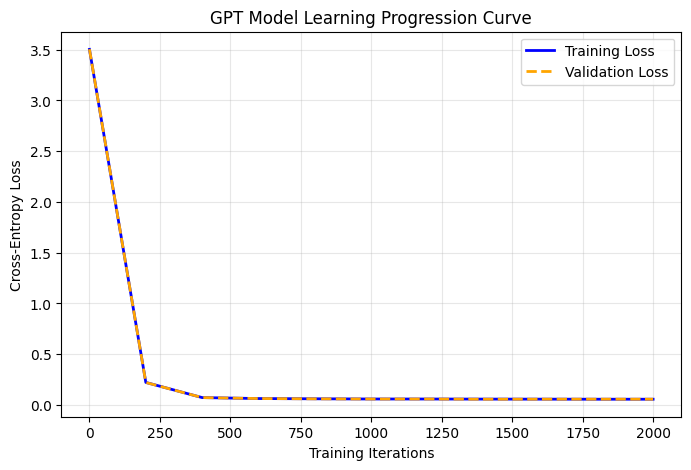

In [6]:
# 5. VISUALIZATION
plt.figure(figsize=(8, 5))
plt.plot(iter_axis, train_loss_history, label='Training Loss', color='blue', lw=2)
plt.plot(iter_axis, val_loss_history, label='Validation Loss', color='orange', linestyle='--', lw=2)
plt.title('GPT Model Learning Progression Curve')
plt.xlabel('Training Iterations')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('loss_curve.png') # Saves visualization automatically
plt.show()

In [7]:
# 6. APPLICATION DEMONSTRATION (Content Generation Prompt)
print("\n--- Application Demo: Copywriting Prompt Completion ---")
seed_phrase = "The world "
context = torch.tensor([encode(seed_phrase)], dtype=torch.long, device=device)
generated_output = decode(model.generate(context, max_new_tokens=150)[0].tolist())

print(f"User Input Prompt: '{seed_phrase}'")
print(f"AI Generated Output:\n{generated_output}")


--- Application Demo: Copywriting Prompt Completion ---
User Input Prompt: 'The world '
AI Generated Output:
The world is a stage of light and shadow, where time stands still in the hearts of those who dream.
To look out at the stars is to look back in time, seeing the
